# Multi-Session JEPSYN Experiment Runner

Train and evaluate the JEPA teacher model & SNN distillation on multi-session neural spike data.

**Make sure you** run the dataset pipeline first (`experiments/data/create_dataset.py`) so a Parquet exists at your config's `data_path`.

In [ ]:
!git clone https://github.com/jacobposchl/jepsyn
!pip install -q torch_brain==0.1.0
!pip install -q snntorch temporaldata umap-learn pyarrow pyyaml

Cloning into 'jepsyn'...
remote: Enumerating objects: 1056, done.
remote: Counting objects: 100% (17/17), done.
remote: Compressing objects: 100% (14/14), done.
remote: Total 1056 (delta 5), reused 5 (delta 3), pack-reused 1039 (from 1)
Receiving objects: 100% (1056/1056), 49.35 MiB | 12.07 MiB/s, done.
Resolving deltas: 100% (637/637), done.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.9/65.9 kB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.5/154.5 kB 17.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 983.4/983.4 kB 71.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
inflect 7.5.0 requires typeguard>=4.0.1, but you have typeguard 2.13.3 which is incompatible.
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 12.8 MB/s

In [ ]:
import os
import sys
from pathlib import Path
from google.colab import drive, files


# The repo is cloned to /content/jepsyn in Colab.
REPO_ROOT = Path("/content/jepsyn")
os.chdir(REPO_ROOT)
print(f"CWD: {Path.cwd()}")

if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))
sys.path.insert(0, str(REPO_ROOT / "experiments" / "multi_session"))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, display

from multi_session import load_and_prepare_data, train_lejepa, load_checkpoint, distill_snn
from jepsyn.utils import evaluate_model, save_results, verify_config
from jepsyn.plots import latent_space

from sklearn.linear_model import Ridge

import torch
from torch import device


print("Imports OK")

CWD: /content/jepsyn
Imports OK


> **Temporary** cell to run after making repo changes.

Pulls changes while preserving loaded information.

In [ ]:
import importlib, sys

!git -C /content/jepsyn pull

# Drop every cached jepsyn / multi_session module so the next import re-reads
# the updated source files from disk.
to_drop = [k for k in sys.modules if k.startswith("jepsyn") or k == "multi_session"]
for k in to_drop:
    del sys.modules[k]

# Re-import everything the notebook depends on.
from multi_session import load_and_prepare_data, train_lejepa, load_checkpoint, distill_snn
from jepsyn.utils import evaluate_model, save_results, verify_config
from jepsyn.plots import latent_space

print(f"Reloaded {len(to_drop)} cached modules.")
print("Hot-reload complete.")

## Configuration

In [ ]:
drive.mount('/content/drive')

# Copy dataset from Drive to local runtime (faster I/O during training).
# Adjust the path below if your Drive folder is named differently.
DRIVE_PARQUET_PATH = "/content/drive/MyDrive/SNN-LeJEPA/Data/Processed Datasets/Visual Cortex/vis_all_animals_dataset.parquet"
LOCAL_DATA_DIR = "/content/jepsyn/datasets"
LOCAL_PARQUET_PATH = f"{LOCAL_DATA_DIR}/vis_all_animals_dataset.parquet"

if os.path.exists(DRIVE_PARQUET_PATH):
    !mkdir -p {LOCAL_DATA_DIR}
    !cp "{DRIVE_PARQUET_PATH}" "{LOCAL_PARQUET_PATH}"
    print(f"Dataset copied to local runtime: {LOCAL_PARQUET_PATH}")
else:
    print("Error: Parquet not found. Check your Drive path.")
    !ls "/content/drive/MyDrive/SNN-LeJEPA/Data/Processed Datasets/Visual Cortex/"


Mounted at /content/drive
Dataset copied to local runtime: /content/jepsyn/datasets/vis_all_animals_dataset.parquet


**CHOOSE MODEL FOR EXPERIMENT**

Options:
- lejepa_visual_cortex.yaml
- vicreg_visual_cortex.yaml
- no_reg_visual_cortex.yaml

In [ ]:
# Point CONFIG_PATH at your experiment YAML to select the model.
# e.g. lejepa_visual_cortex.yaml (SIGReg), vicreg_visual_cortex.yaml (VICReg)
CONFIG_PATH = Path("experiments/multi_session/configs/no_reg_visual_cortex.yaml")

config = verify_config(CONFIG_PATH)

tcfg = config["training_config"]
mcfg = config["model_config"]
reg_type = tcfg.get("reg_type", "sigreg").lower()

print(f"Config loaded:      {CONFIG_PATH}")
print(f"data_path:          {config['data_path']}")
print(f"results_out_path:   {config.get('results_out_path', '(not set — results will not be saved to disk)')}")
print()
print(f"reg_type:           {reg_type}")
print(f"epochs:             {tcfg.get('epochs', 100)}")
print(f"batch_size:         {tcfg.get('batch_size', 32)}")
print(f"lr:                 {tcfg.get('lr', 1e-4)}")
print(f"mask_ratio:         {tcfg.get('mask_ratio', 0.5)}")
print(f"ema_momentum:       {tcfg.get('ema_momentum', 0.996)}")
if reg_type == "vicreg":
    print(f"vic_sim:            {tcfg.get('vic_sim', 25.0)}")
    print(f"vic_std:            {tcfg.get('vic_std', 25.0)}")
    print(f"vic_cov:            {tcfg.get('vic_cov', 1.0)}")
else:
    print(f"lambd (SIGReg):     {tcfg.get('lambd', 0.05)}")
    print(f"num_slices:         {tcfg.get('num_slices', 256)}")
print(f"unit_dropout:       {tcfg.get('unit_dropout', 0.0)}")
print(f"unit_id_steps:      {tcfg.get('unit_id_steps', 200)}")
print(f"unit_id_lr:         {tcfg.get('unit_id_lr', 1e-3)}")
print()
print(f"d_model:            {mcfg.get('d_model', 256)}")
print(f"n_latents:          {mcfg.get('n_latents', 64)}")
print(f"window_size_s:      {mcfg.get('window_size_s', 0.4)}")
print(f"rope_t_min:         {mcfg.get('rope_t_min', 1e-3)}")
print(f"rope_t_max:         {mcfg.get('rope_t_max', 4.0)}")
print(f"use_delimiter_tokens: {mcfg.get('use_delimiter_tokens', True)}")

Config loaded:      experiments/multi_session/configs/no_reg_visual_cortex.yaml
data_path:          /content/jepsyn/datasets/vis_all_animals_dataset.parquet
results_out_path:   /content/jepsyn/results/ablation_no_reg

reg_type:           no_reg
epochs:             100
batch_size:         32
lr:                 0.0001
mask_ratio:         0.5
ema_momentum:       0.99
lambd (SIGReg):     0.0
num_slices:         256
unit_dropout:       0.4
unit_id_steps:      200
unit_id_lr:         0.0001

d_model:            256
n_latents:          64
window_size_s:      0.4
rope_t_min:         0.001
rope_t_max:         4.0
use_delimiter_tokens: True


> **OPTIONAL**: Run this cell only if you have a previously saved checkpoint on Drive and want to skip training.
>
> After running it, skip down to the **Test Evaluation** section.


In [ ]:
# OPTIONAL: Load a previously saved checkpoint from Drive instead of training.
CKPT_PATH = Path("/content/drive/MyDrive/SNN-LeJEPA/Data/Model Results/lejepa_checkpoint.pt")

jepa_model, config, unit_maps = load_checkpoint(CKPT_PATH)
print("Checkpoint loaded. Skip down to Test Evaluation.")


## Data Loading

Loads the Parquet from `data_path`, validates schema and integrity, then splits windows by `session_id` into train / val / test sets.

In [ ]:
train_loader, test_loader, unit_maps, test_session_ids = load_and_prepare_data(config)

print(f"Sessions in unit_maps: {len(unit_maps)}")
print(f"Units per session:     min={min(len(m) for m in unit_maps.values())}, max={max(len(m) for m in unit_maps.values())}")
print(f"Train batches:         {len(train_loader)}")
print(f"Test batches:          {len(test_loader)}")
print(f"Test session IDs:      {test_session_ids}")


Validating dataset integrity...
Passed basic validation checks.
Built unit maps for 103 sessions (sizes: [554, 488, 554, 518, 494, 464, 487, 509, 425, 599, 599, 462, 488, 431, 396, 557, 423, 311, 490, 465, 371, 504, 569, 443, 502, 548, 608, 451, 609, 701, 490, 550, 405, 487, 522, 451, 466, 397, 439, 529, 696, 734, 586, 526, 399, 599, 501, 479, 660, 685, 375, 454, 649, 489, 624, 394, 686, 712, 609, 473, 651, 483, 412, 429, 600, 739, 546, 298, 450, 324, 606, 736, 512, 685, 415, 602, 738, 515, 637, 729, 541, 702, 545, 616, 400, 928, 607, 505, 414, 610, 563, 513, 494, 563, 477, 539, 554, 554, 471, 637, 397, 566, 633])
Train: 34734 windows (72 sessions)
Test:  15186 windows (31 sessions)
Sessions in unit_maps: 103
Units per session:     min=298, max=928
Train batches:         1086
Test batches:          475
Test session IDs:      [1044385384, 1048189115, 1052342277, 1052533639, 1053718935, 1055221968, 1055415082, 1064415305, 1065449881, 1067781390, 1069461581, 1081079981, 1087720624, 108799

## Training
> **Skip this entire section if you loaded a checkpoint above.**

Trains the **context encoder** (online, gradients flow), **target encoder** (EMA copy, no gradients), and **predictor** (narrow Transformer).

Regularization is selected by `reg_type` in your config:
- **SIGReg** (default): `total = (1 - λ) * MSE(h_pred, h_tgt) + λ * SIGReg(h_ctx, h_tgt)`
- **VICReg**: `total = vic_sim * MSE(h_pred, h_tgt) + vic_std * var_loss + vic_cov * cov_loss`

After training, the checkpoint is saved to `<results_out_path>/lejepa_checkpoint.pt`.

In [ ]:
jepa_model, jepa_train_metrics = train_lejepa(config, train_loader, unit_maps)
print("Training complete.")
jepa_train_metrics.tail()


Training on cuda


/content/jepsyn/jepsyn/models/predictor.py:50: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  self.blocks = nn.TransformerEncoder(


Epoch   0 | train=0.0122 | pred=0.0122 (100.0%) | reg=0.0000 (0.0%)
Epoch   1 | train=0.0059 | pred=0.0059 (100.0%) | reg=0.0000 (0.0%)
Epoch   2 | train=0.0029 | pred=0.0029 (100.0%) | reg=0.0000 (0.0%)
Epoch   3 | train=0.0024 | pred=0.0024 (100.0%) | reg=0.0000 (0.0%)
Epoch   4 | train=0.0067 | pred=0.0067 (100.0%) | reg=0.0000 (0.0%)
Epoch   5 | train=0.0035 | pred=0.0035 (100.0%) | reg=0.0000 (0.0%)
Epoch   6 | train=0.0024 | pred=0.0024 (100.0%) | reg=0.0000 (0.0%)
Epoch   7 | train=0.0030 | pred=0.0030 (100.0%) | reg=0.0000 (0.0%)
Epoch   8 | train=0.0035 | pred=0.0035 (100.0%) | reg=0.0000 (0.0%)
Epoch   9 | train=0.0009 | pred=0.0009 (100.0%) | reg=0.0000 (0.0%)
Epoch  10 | train=0.0022 | pred=0.0022 (100.0%) | reg=0.0000 (0.0%)
Epoch  11 | train=0.0005 | pred=0.0005 (100.0%) | reg=0.0000 (0.0%)
Epoch  12 | train=0.0017 | pred=0.0017 (100.0%) | reg=0.0000 (0.0%)
Epoch  13 | train=0.0004 | pred=0.0004 (100.0%) | reg=0.0000 (0.0%)
Epoch  14 | train=0.0002 | pred=0.0002 (100.0%) 

,epoch,train_loss,train_pred_loss,train_reg_loss
95,95,0.000019,0.000019,0.0
96,96,0.000019,0.000019,0.0
97,97,0.000018,0.000018,0.0
98,98,0.000017,0.000017,0.0
99,99,0.000018,0.000018,0.0


## Training Results

In [ ]:
save_results(stage="LeJEPA", phase="training", metrics=jepa_train_metrics, config=config)

DRIVE_RESULTS_DIR = "/content/drive/MyDrive/SNN-LeJEPA/Data/Model Results"
!mkdir -p "{DRIVE_RESULTS_DIR}"
!cp results/lejepa_checkpoint.pt "{DRIVE_RESULTS_DIR}/lejepa_checkpoint.pt"
print(f"Checkpoint saved to Drive: {DRIVE_RESULTS_DIR}/lejepa_checkpoint.pt")


Saved metrics to /content/jepsyn/results/ablation_no_reg/LeJEPA/training/metrics.csv
Saved training curves to /content/jepsyn/results/ablation_no_reg/LeJEPA/training/training_curves.png
cp: cannot stat 'results/lejepa_checkpoint.pt': No such file or directory
Checkpoint saved to Drive: /content/drive/MyDrive/SNN-LeJEPA/Data/Model Results/lejepa_checkpoint.pt


Visualize Results Plots

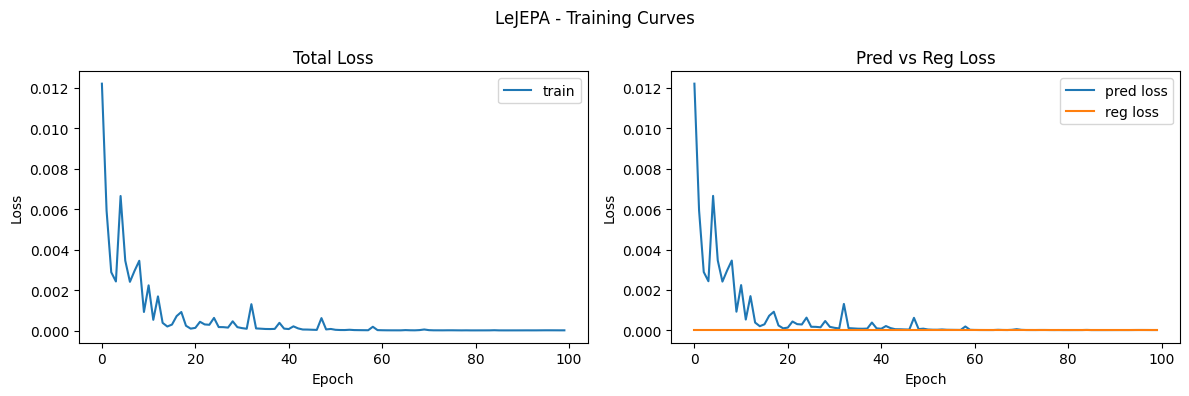

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("LeJEPA - Training Curves")

axes[0].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_loss"], label="train")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Total Loss")
axes[0].legend()

axes[1].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_pred_loss"], label="pred loss")
axes[1].plot(jepa_train_metrics["epoch"], jepa_train_metrics["train_reg_loss"], label="reg loss")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Loss")
axes[1].set_title("Pred vs Reg Loss")
axes[1].legend()

plt.tight_layout()
plt.show()


## Test Evaluation
> **← Resume here if you loaded a checkpoint.**

Runs the full test pipeline in sequence:
1. **Unit identification** — adapts test-session unit embedding tables using the self-supervised JEPA objective (no labels, ~200 steps). Required before any meaningful evaluation on held-out sessions.
2. **JEPA metrics** — pred_loss, cosine similarity, R², CKA (secondary/debug output).
3. **Linear probes** — fits 5-fold cross-validated logistic regression on frozen target representations to decode `is_change`, `image_name`, and `session_id`.

In [ ]:
jepa_test_metrics, probe_results = evaluate_model(
    jepa_model, test_loader,
    stage="LeJEPA",
    test_session_ids=test_session_ids,
    config=config,
)

probe_df = pd.DataFrame(probe_results).T

results_path = config.get("results_out_path")
if results_path:
    probe_csv = Path(results_path) / "LeJEPA" / "test" / "probe_results.csv"
    probe_csv.parent.mkdir(parents=True, exist_ok=True)
    probe_df.to_csv(probe_csv)
    print(f"Saved probe results to {probe_csv}")

probe_df


[Unit ID] Adapting 31 test-session unit tables (4,325,632 params) for 200 steps  lr=0.0001
  step  50/200 | loss=0.0001 | pred=0.0001
  step 100/200 | loss=0.0002 | pred=0.0002
  step 150/200 | loss=0.0001 | pred=0.0001
  step 200/200 | loss=0.0001 | pred=0.0001
  Syncing adapted unit embeds → target encoder...
[Unit ID] Done.


[LeJEPA] JEPA Metrics (debug):
pred_loss         0.007696
cos_similarity    0.988168
r2               -0.361470
cka               0.676600

[LeJEPA] Linear Probe  (representation dim=256, N=15186)
  Probe 1 — is_change        | balanced acc: 0.664 ± 0.018 | AUROC: 0.700  (chance=0.500)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

  Probe 2 — image identity   | 14 classes | balanced acc: 0.173 ± 0.006 | AUROC: 0.730  (chance=0.071)
  Probe 3 — session identity | 31 sessions | balanced acc: 0.957 ± 0.002  (chance=0.032)
Saved probe results to /content/jepsyn/results/ablation_no_reg/LeJEPA/test/probe_results.csv


,balanced_acc,balanced_acc_std,auroc,chance,n,n_classes,n_sessions
is_change,0.663723,0.018342,0.700020,0.500000,15186.0,NaN,NaN
image_name,0.173286,0.005762,0.729512,0.071429,15186.0,14.0,NaN
session_id,0.956847,0.002248,NaN,0.032258,15186.0,NaN,31.0


Visualize Model Probing Results

Fitting UMAP…


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


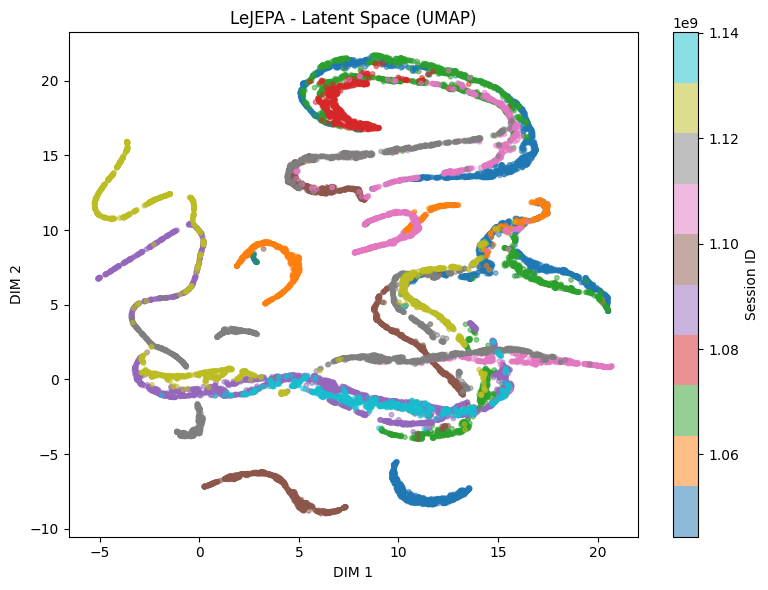

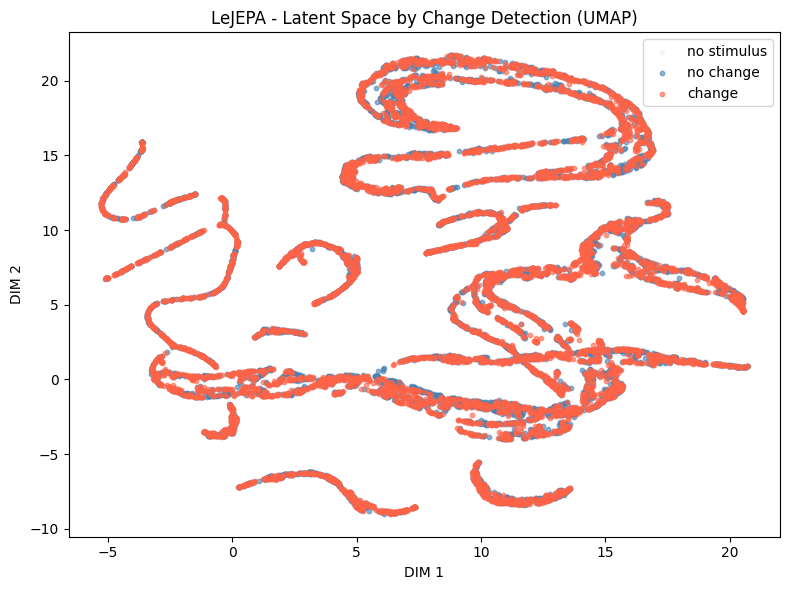

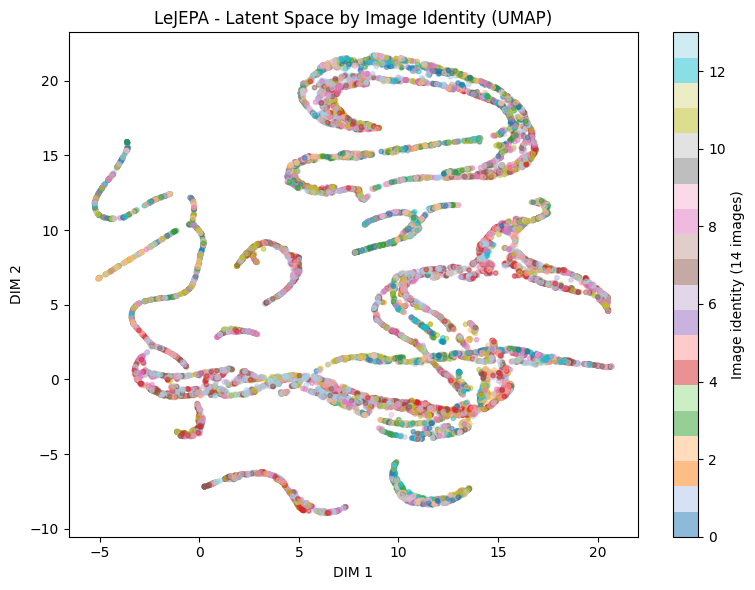

In [ ]:
latent_vectors = np.vstack(jepa_test_metrics["h_tgt"].values)
session_labels = np.concatenate(jepa_test_metrics["session_ids"].values)
is_change_arr  = np.concatenate(jepa_test_metrics["is_change"].values).astype(int)
stim_block_arr = np.concatenate(jepa_test_metrics["stim_block"].values)
image_name_arr = np.array(
    [x for sub in jepa_test_metrics["image_name"].values for x in sub], dtype=object
)

print("Fitting UMAP…")
fig_session, embeddings2d = latent_space.plot_umap_by_session(
    latent_vectors, session_labels, stage="LeJEPA"
)
plt.show()

valid = stim_block_arr >= 0
if valid.sum() >= 10:
    fig_change = latent_space.plot_umap_by_change(
        embeddings2d, is_change_arr, valid, stage="LeJEPA"
    )
    plt.show()

has_image = np.array([x is not None for x in image_name_arr])
if has_image.sum() >= 10:
    fig_image = latent_space.plot_umap_by_image(
        embeddings2d[has_image], image_name_arr[has_image], stage="LeJEPA"
    )
    plt.show()

Download the Evaluation Results

In [ ]:
!zip -r LeJEPA_export.zip results
files.download('LeJEPA_export.zip')

  adding: results/ (stored 0%)
  adding: results/ablation_no_reg/ (stored 0%)
  adding: results/ablation_no_reg/lejepa_checkpoint.pt (deflated 8%)
  adding: results/ablation_no_reg/LeJEPA/ (stored 0%)
  adding: results/ablation_no_reg/LeJEPA/test/ (stored 0%)
  adding: results/ablation_no_reg/LeJEPA/test/probe_results.csv (deflated 41%)
  adding: results/ablation_no_reg/LeJEPA/training/ (stored 0%)
  adding: results/ablation_no_reg/LeJEPA/training/metrics.csv (deflated 70%)
  adding: results/ablation_no_reg/LeJEPA/training/training_curves.png (deflated 9%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# SNN Distillation

In [ ]:
snn_model, snn_metrics = distill_snn(config, jepa_model, train_loader)
print("SNN Distillation Complete.")


_LinAlgError: linalg.eigh: The algorithm failed to converge because the input matrix is ill-conditioned or has too many repeated eigenvalues (error code: 257).

## SNN Evaluation

Linear probes and UMAP on the SNN student's membrane potential representations (`mem.mean(dim=1)`).
Compare with the JEPA teacher probes above.

Good distillation means the probe scores should be similar.

In [ ]:
snn_metrics, snn_probe_results = evaluate_model(
    snn_model, test_loader, stage="SNN", teacher_model=jepa_model
)

pd.DataFrame(snn_probe_results).T

Visualize SNN Probe UMAPs

In [ ]:
snn_latent_vectors = np.vstack(snn_metrics["h_tgt"].values)
snn_session_labels = np.concatenate(snn_metrics["session_ids"].values)
snn_is_change_arr  = np.concatenate(snn_metrics["is_change"].values).astype(int)
snn_stim_block_arr = np.concatenate(snn_metrics["stim_block"].values)
snn_image_name_arr = np.array(
    [x for sub in snn_metrics["image_name"].values for x in sub], dtype=object
)

print("Fitting UMAP for SNN representations…")
fig_snn_session, snn_embeddings2d = latent_space.plot_umap_by_session(
    snn_latent_vectors, snn_session_labels, stage="SNN"
)
plt.show()

snn_valid = snn_stim_block_arr >= 0
if snn_valid.sum() >= 10:
    fig_snn_change = latent_space.plot_umap_by_change(
        snn_embeddings2d, snn_is_change_arr, snn_valid, stage="SNN"
    )
    plt.show()

snn_has_image = np.array([x is not None for x in snn_image_name_arr])
if snn_has_image.sum() >= 10:
    fig_snn_image = latent_space.plot_umap_by_image(
        snn_embeddings2d[snn_has_image], snn_image_name_arr[snn_has_image], stage="SNN"
    )
    plt.show()